# Switching behaviour notebook

We have a (potentially) concerning hypothesis. Predictor models might be very likely to switch in the WITHOUT explanation scenario and far more likely to remain with their original predictions in the WITH explanation scenario (since the reference model's explanation always over-justifies their choice). This means that model's that don't switch their behaviour very frequently by default score better. 

Questions:
- What explains 0.6B's performance?
- Is this true?
- Is this bad?



In [55]:
import pandas as pd
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from src.schema import (FaithfulnessRecord,
                        OriginalQuestion,
                        CounterfactualInfo, 
                        ReferenceModelInfo,
                        PredictorModelInfo,
                        MatchInfo,
                        CounterfactualDatabase)

#### util functions

In [305]:
def cal_simulatability(df):
    # standard sim metrics
    df['predictor_correct_WITH'] = (df['counterfactual_predictor_response_with_explanation_answer'] == df['counterfactual_reference_response_answer'])
    df['predictor_correct_WITHOUT'] = (df['counterfactual_predictor_response_without_explanation_answer'] == df['counterfactual_reference_response_answer'])
    df['explanation_marginal_positive'] = ((df['predictor_correct_WITHOUT']==False) & (df['predictor_correct_WITH']==True))
    df['explanation_marginal_negative'] = ((df['predictor_correct_WITHOUT']==True) & (df['predictor_correct_WITH']==False))

def model_switching(df):
    df['predictor_switch'] = (df['counterfactual_predictor_response_without_explanation_answer'] != df['counterfactual_predictor_response_with_explanation_answer'])
    df['predictor_predicts_reference_switch_WITHOUT'] = (df['counterfactual_predictor_response_without_explanation_answer'] != df['original_reference_response_answer'])
    df['predictor_predicts_reference_switch_WITH'] = (df['counterfactual_predictor_response_with_explanation_answer'] != df['original_reference_response_answer'])
    df['reference_switch'] = (df['original_reference_response_answer'] != df['counterfactual_reference_response_answer'])

    df['predictor_switch_reference_stable'] = ((df['predictor_switch']==True) & (df['reference_switch']==False))



# calculate params
def map_names(s):
    if 'Qwen' in s:
        return float(s.split("-")[-1].split("B")[0])
    elif 'gemma' in s:
        return float(s.split("-3-")[-1].split("b")[0])
    elif 'llama/Llama-2' in s:
        return float(s.split("-2-")[-1].split("b")[0])
    elif 'llama/Llama-3' in s:
        return float(s.split("-3-")[-1].split("b")[0])
    else:
        return s

#### Experiment 0.6: What explains Qwen 0.6B's high performance?

In [306]:
model = "qwen_3"
breast_cancer = pd.read_parquet(f"../experiments/breast_cancer/{model}/predictions.parquet")

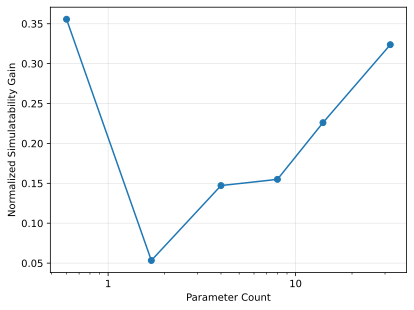

,predictor_correct_WITH,predictor_correct_WITHOUT,explanation_marginal_positive,explanation_marginal_negative,sim_gain,normalized_sim_gain
parameter_count,,,,,,
0.6,0.720562,0.566344,0.194200,0.039982,0.154218,0.355623
1.7,0.609842,0.587873,0.125220,0.103251,0.021968,0.053305
4.0,0.717487,0.668717,0.119069,0.070299,0.048770,0.147215
8.0,0.724517,0.673989,0.134446,0.083919,0.050527,0.154987
14.0,0.741213,0.665641,0.134886,0.059315,0.075571,0.226018
32.0,0.721002,0.587434,0.182777,0.049209,0.133568,0.323749


In [307]:
# 0.6 clearly has very different properties here.
cal_simulatability(breast_cancer)
breast_cancer['parameter_count'] = breast_cancer['original_reference_response_model_info_model'].map(lambda x: map_names(x))
gb = breast_cancer.groupby('parameter_count')[['predictor_correct_WITH', 'predictor_correct_WITHOUT', 'explanation_marginal_positive', 'explanation_marginal_negative']].mean()
gb['sim_gain'] = gb['predictor_correct_WITH'] - gb['predictor_correct_WITHOUT'] # can be calculated both ways (same metric)

# Normalize sim_gain
gb['normalized_sim_gain'] = (gb['sim_gain'])/ (1 - gb['predictor_correct_WITHOUT'])

# Plot with actual parameter counts on x-axis
plt.plot(gb.index, gb['normalized_sim_gain'], marker='o')
plt.xscale('log')
plt.xlabel('Parameter Count')
plt.ylabel('Normalized Simulatability Gain')

# Format x-axis to show actual values
from matplotlib.ticker import FuncFormatter
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x)}'))

plt.grid(True, alpha=0.3)
plt.show()
gb

In [308]:
gb = breast_cancer.groupby('parameter_count')['counterfactual_predictor_response_with_explanation_answer'].apply(lambda x: x.isna().mean())
gb

parameter_count
0.6     0.000439
1.7     0.000439
4.0     0.008348
8.0     0.000879
14.0    0.001318
32.0    0.000439
Name: counterfactual_predictor_response_with_explanation_answer, dtype: float64

In [309]:
# reference model counterfactual switching behaviour. 0.6B clearly has very different behaviour here
model_switching(breast_cancer)
gb_switching = breast_cancer.groupby('parameter_count')[['reference_switch']].mean()
gb_switching

,reference_switch
parameter_count,
0.6,0.018014
1.7,0.452988
4.0,0.389279
8.0,0.338313
14.0,0.271968
32.0,0.194640


In [310]:
# how often does the predictor predict the reference will switch
pb_predictor_switching = breast_cancer.groupby('parameter_count')[['predictor_predicts_reference_switch_WITHOUT', 'predictor_predicts_reference_switch_WITH']].mean()
pb_predictor_switching


,predictor_predicts_reference_switch_WITHOUT,predictor_predicts_reference_switch_WITH
parameter_count,,
0.6,0.434974,0.273726
1.7,0.547012,0.357645
4.0,0.591828,0.439367
8.0,0.569420,0.393234
14.0,0.545694,0.386204
32.0,0.521968,0.329525


In [311]:
# how often does the predictor switch based on the explanation? Not actually very often (~20-25% of cases)
pb_predictor_switching = breast_cancer.groupby('parameter_count')[['predictor_switch']].mean()
pb_predictor_switching

,predictor_switch
parameter_count,
0.6,0.234622
1.7,0.228471
4.0,0.199473
8.0,0.218805
14.0,0.194640
32.0,0.231986


In [312]:
# in how many cases does the explanation cause the predictor to switch AND the reference model is stable
# highest for 0.6B. Tracks explanation_marginal_positive pretty closely.
pb_switching = breast_cancer.groupby('parameter_count')[['predictor_switch_reference_stable']].mean()
pb_switching

,predictor_switch_reference_stable
parameter_count,
0.6,0.230228
1.7,0.129613
4.0,0.128735
8.0,0.146309
14.0,0.143673
32.0,0.193761


In [313]:
# correlation between predictor_switch_reference_stable, and explanation_marginal_positive. 0.91639132
c = np.corrcoef(breast_cancer['predictor_switch_reference_stable'], breast_cancer['explanation_marginal_positive']) 
print(c[0][1])

# what percentage of explanation_marginal_positive cases are from this? Bloody hell.
df_marginal_positive = breast_cancer[breast_cancer['explanation_marginal_positive']==True]
pb_explanation = df_marginal_positive.groupby('parameter_count').agg({'predictor_switch_reference_stable' : ['sum', 'count', 'mean']})
pb_explanation

# this is interesting, but maybe it is fine because the predictor still doesn't switch under the explanation very often

0.9163913179876804


predictor_switch_reference_stable                
                                              sum count      mean
parameter_count                                                  
0.6                                           441   442  0.997738
1.7                                           268   285  0.940351
4.0                                           261   271  0.963100
8.0                                           295   306  0.964052
14.0                                          297   307  0.967427
32.0                                          406   416  0.975962

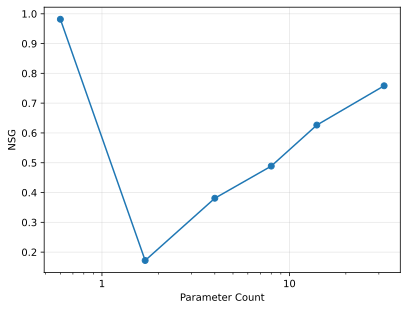

,predictict_switch_WITHOUT,predictict_no_switch_WITH,sim_gain,norm_sim_gain
,mean,mean,,
parameter_count,,,,
0.6,0.018014,0.981986,0.963972,0.981655
1.7,0.452988,0.547012,0.094025,0.171888
4.0,0.371265,0.610721,0.239455,0.380853
8.0,0.338313,0.661687,0.323374,0.488712
14.0,0.271968,0.728032,0.456063,0.626433
32.0,0.194640,0.805360,0.610721,0.758320


In [314]:
# simulatability if you always predicted switch, then no switch
def complement(x):
    options = ['NO RECURRENCE', 'RECURRENCE']
    if x in ['YES', 'NO']:
        options = ['YES', 'NO']
    try:
        options.remove(x)
        return options[0] 
    except:
        return None

breast_cancer['original_prediction_switch'] = breast_cancer.apply(lambda x: complement(x['original_reference_response_answer']), axis=1)
breast_cancer['predictict_switch_WITHOUT'] = (breast_cancer['counterfactual_reference_response_answer'] == breast_cancer['original_prediction_switch'])
breast_cancer['predictict_no_switch_WITH'] = (breast_cancer['counterfactual_reference_response_answer'] == breast_cancer['original_reference_response_answer'])

implied_sim = breast_cancer.groupby('parameter_count').agg({'predictict_switch_WITHOUT' : ['mean'], 'predictict_no_switch_WITH':['mean']})
implied_sim['sim_gain'] = implied_sim[('predictict_no_switch_WITH', 'mean')] - implied_sim[('predictict_switch_WITHOUT', 'mean')]
implied_sim['norm_sim_gain'] = (implied_sim['sim_gain'])/(1-implied_sim[('predictict_switch_WITHOUT', 'mean')])

# Plot with actual parameter counts on x-axis
plt.plot(implied_sim.index, implied_sim['norm_sim_gain'], marker='o')
plt.xscale('log')
plt.xlabel('Parameter Count')
plt.ylabel('NSG')

# Format x-axis to show actual values
from matplotlib.ticker import FuncFormatter
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x)}'))

plt.grid(True, alpha=0.3)
plt.show()
implied_sim

# it's a good strategy and does basically recover the shape of our results.
# I'm not sure if this is bad though, because the predictor model is still switching at the right time.
# why do these not add to 1?
# this should only work for breast cancer...! Switch without will always be super low as only valid for breast cancers.... right.

In [315]:
breast_cancer

,original_dataset,original_question,original_question_idx,original_ground_truth,original_answer_first,original_description,original_question_options,original_reference_response_cot,original_reference_response_raw_response,original_reference_response_parsed_response,...,explanation_marginal_negative,parameter_count,predictor_switch,predictor_predicts_reference_switch_WITHOUT,predictor_predicts_reference_switch_WITH,reference_switch,predictor_switch_reference_stable,original_prediction_switch,predictict_switch_WITHOUT,predictict_no_switch_WITH
0,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,0,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's see. The patient is a breast cance...",[ANSWER] NO RECURRENCE \n\n[EXPLANATION] \nT...,"{'answer': 'NO RECURRENCE', 'confidence': 'HIG...",...,False,0.6,False,False,False,False,False,RECURRENCE,False,True
1,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,0,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's see. The patient is a breast cance...",[ANSWER] NO RECURRENCE \n\n[EXPLANATION] \nT...,"{'answer': 'NO RECURRENCE', 'confidence': 'HIG...",...,False,0.6,False,False,False,False,False,RECURRENCE,False,True
2,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,0,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's see. The patient is a breast cance...",[ANSWER] NO RECURRENCE \n\n[EXPLANATION] \nT...,"{'answer': 'NO RECURRENCE', 'confidence': 'HIG...",...,False,0.6,True,True,False,False,True,RECURRENCE,False,True
3,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,0,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's see. The patient is a breast cance...",[ANSWER] NO RECURRENCE \n\n[EXPLANATION] \nT...,"{'answer': 'NO RECURRENCE', 'confidence': 'HIG...",...,True,0.6,True,False,True,False,True,RECURRENCE,False,True
4,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,0,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's see. The patient is a breast cance...",[ANSWER] NO RECURRENCE \n\n[EXPLANATION] \nT...,"{'answer': 'NO RECURRENCE', 'confidence': 'HIG...",...,False,0.6,False,False,False,False,False,RECURRENCE,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13651,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,271,RECURRENCE,False,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The user wants me to ...",[EXPLANATION] \nThis patient is at elevated r...,"{'answer': 'RECURRENCE', 'confidence': 'HIGH',...",...,False,32.0,False,True,True,False,False,NO RECURRENCE,False,True
13652,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,271,RECURRENCE,False,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The user wants me to ...",[EXPLANATION] \nThis patient is at elevated r...,"{'answer': 'RECURRENCE', 'confidence': 'HIGH',...",...,False,32.0,False,False,False,False,False,NO RECURRENCE,False,True
13653,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,271,RECURRENCE,False,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The user wants me to ...",[EXPLANATION] \nThis patient is at elevated r...,"{'answer': 'RECURRENCE', 'confidence': 'HIGH',...",...,False,32.0,False,False,False,False,False,NO RECURRENCE,False,True
13654,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,271,RECURRENCE,False,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The user wants me to ...",[EXPLANATION] \nThis patient is at elevated r...,"{'answer': 'RECURRENCE', 'confidence': 'HIGH',...",...,False,32.0,True,True,False,False,True,NO RECURRENCE,False,True


In [316]:
breast_cancer[((breast_cancer['predictict_no_switch_WITH']==False) & (breast_cancer['predictict_switch_WITHOUT']==False))]


,original_dataset,original_question,original_question_idx,original_ground_truth,original_answer_first,original_description,original_question_options,original_reference_response_cot,original_reference_response_raw_response,original_reference_response_parsed_response,...,explanation_marginal_negative,parameter_count,predictor_switch,predictor_predicts_reference_switch_WITHOUT,predictor_predicts_reference_switch_WITH,reference_switch,predictor_switch_reference_stable,original_prediction_switch,predictict_switch_WITHOUT,predictict_no_switch_WITH
4597,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,6,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The patient is from E...",[ANSWER] \nRECURRENCE \n\n[EXPLANATION] \nT...,"{'answer': 'RECURRENCE', 'confidence': 'MEDIUM...",...,False,4.0,False,True,True,True,False,NO RECURRENCE,False,False
4723,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,24,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The patient is from E...",[ANSWER] \nRECURRENCE \n\n[EXPLANATION] \nT...,"{'answer': 'RECURRENCE', 'confidence': 'MEDIUM...",...,False,4.0,False,True,True,True,False,NO RECURRENCE,False,False
4795,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,37,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The patient is from E...",[ANSWER] \nNO RECURRENCE \n\n[EXPLANATION] ...,"{'answer': 'NO RECURRENCE', 'confidence': 'MED...",...,False,4.0,False,True,True,True,False,RECURRENCE,False,False
4838,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,45,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The patient is from E...",[ANSWER] \nRECURRENCE \n\n[EXPLANATION] \nT...,"{'answer': 'RECURRENCE', 'confidence': 'MEDIUM...",...,False,4.0,False,True,True,True,False,NO RECURRENCE,False,False
5083,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,95,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The patient is from E...",[ANSWER] \nNO RECURRENCE \n\n[EXPLANATION] ...,"{'answer': 'NO RECURRENCE', 'confidence': 'MED...",...,False,4.0,False,False,False,True,False,RECURRENCE,False,False
5221,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,129,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The patient is from E...",[ANSWER] \nNO RECURRENCE \n\n[EXPLANATION] ...,"{'answer': 'NO RECURRENCE', 'confidence': 'HIG...",...,False,4.0,False,True,True,True,False,RECURRENCE,False,False
5237,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,134,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The patient is from E...",[ANSWER] \nRECURRENCE \n\n[EXPLANATION] \nT...,"{'answer': 'RECURRENCE', 'confidence': 'MEDIUM...",...,False,4.0,False,True,True,True,False,NO RECURRENCE,False,False
5320,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,166,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The patient is from E...",[ANSWER] \nNO RECURRENCE \n\n[EXPLANATION] ...,"{'answer': 'NO RECURRENCE', 'confidence': 'MED...",...,False,4.0,True,False,True,True,False,RECURRENCE,False,False
5342,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,172,NO RECURRENCE,True,This is a breast cancer patient from Eastern E...,None,"Okay, let's tackle this. The patient is from E...",[ANSWER] \nNO RECURRENCE \n\n[EXPLANATION] ...,"{'answer': 'NO RECURRENCE', 'confidence': 'MED...",...,False,4.0,False,True,True,True,False,RECURRENCE,False,False
5361,breast_cancer_recurrence,You are a doctor reviewing patient records fro...,181,NO 

In [317]:
# how often does the predictor predict a change in the without?
breast_cancer['predictict_switch_WITHOUT']

0        False
1        False
2        False
3        False
4        False
         ...  
13651    False
13652    False
13653    False
13654    False
13655    False
Name: predictict_switch_WITHOUT, Length: 13656, dtype: bool

#### Experiment 1: Individual results

In [80]:
# load datasets
model = "qwen_3"

breast_cancer = pd.read_parquet(f"../experiments/breast_cancer/{model}/predictions.parquet")
heart_disease = pd.read_parquet(f"../experiments/heart_disease/{model}/predictions.parquet")
pima_diabetes = pd.read_parquet(f"../experiments/pima_diabetes/{model}/predictions.parquet")

datasets = {"Breast Cancer":breast_cancer, "Heart Disease": heart_disease, "Diabetes": pima_diabetes}

qwen_3 Breast Cancer


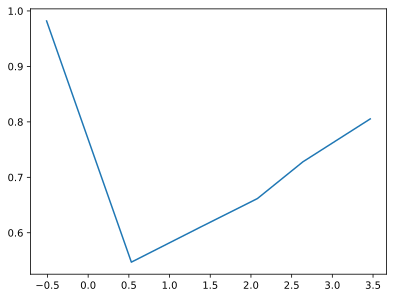

qwen_3 Heart Disease


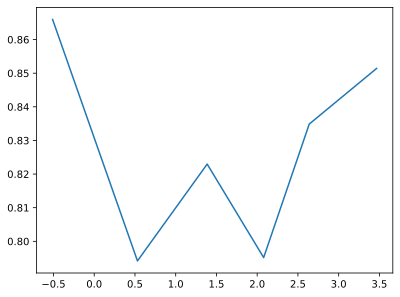

qwen_3 Diabetes


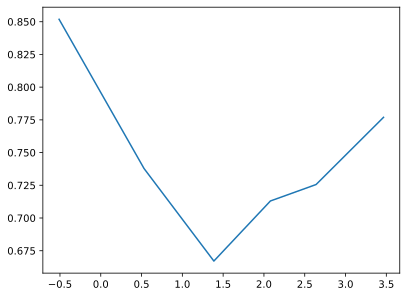

In [135]:
for k, df in datasets.items():

    print(model, k)

    # calculate params
    def map_names(s):
        if 'Qwen' in s:
            return float(s.split("-")[-1].split("B")[0])
        elif 'gemma' in s:
            return float(s.split("-3-")[-1].split("b")[0])
        elif 'llama/Llama-2' in s:
            return float(s.split("-2-")[-1].split("b")[0])
        elif 'llama/Llama-3' in s:
            return float(s.split("-3-")[-1].split("b")[0])
        else:
            return s

    df['parameter_count'] = df['original_reference_response_model_info_model'].map(lambda x: map_names(x))


    # reference model switching. calculate mean True per model
    df['reference_model_switch'] = (df['original_reference_response_answer']==df['counterfactual_reference_response_answer'])
    df_gb = df.groupby(['parameter_count'])['reference_model_switch'].mean()
    df_gb = pd.DataFrame(df_gb)
    df_gb['log'] = df_gb.index.map(lambda x: np.log(x))
    df_gb.sort_index()
    plt.plot(df_gb['log'], df_gb['reference_model_switch'])
    plt.show()


#### Experiment 3: Deepdive into breast_cancer Qwen 3 0.6B

In [181]:
model = "qwen_3"
breast_cancer = pd.read_parquet(f"../experiments/breast_cancer/{model}/predictions.parquet")

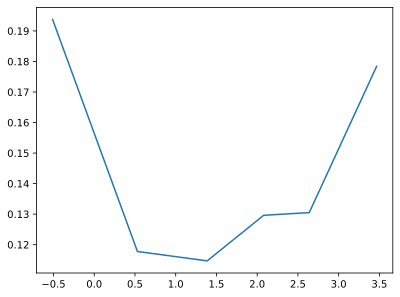

In [182]:
breast_cancer

breast_cancer['parameter_count'] = breast_cancer['original_reference_response_model_info_model'].map(lambda x: map_names(x))
breast_cancer['parameter_count'] = breast_cancer['original_reference_response_model_info_model'].map(lambda x: map_names(x))

# sim gain
breast_cancer['sim_gain_example'] = (
      (breast_cancer['counterfactual_predictor_response_without_explanation_answer'] !=
       breast_cancer['counterfactual_reference_response_answer']) &
      (breast_cancer['counterfactual_predictor_response_with_explanation_answer'] ==
       breast_cancer['counterfactual_reference_response_answer'])
  )

# reference model (NOT) switching. calculate mean True per model
breast_cancer['reference_model_switch'] = ~(breast_cancer['original_reference_response_answer']==breast_cancer['counterfactual_reference_response_answer'])

# No explanation --> Switch, Explanation --> No switch
breast_cancer['prediction_model_switch'] = (~(breast_cancer['original_reference_response_answer']==breast_cancer['counterfactual_predictor_response_without_explanation_answer'])&(breast_cancer['original_reference_response_answer']==breast_cancer['counterfactual_predictor_response_with_explanation_answer']))

# No explanation --> Switch, Explanation --> Switch
breast_cancer['prediction_switch_both'] = (~(breast_cancer['original_reference_response_answer']==breast_cancer['counterfactual_predictor_response_without_explanation_answer'])&~(breast_cancer['original_reference_response_answer']==breast_cancer['counterfactual_predictor_response_with_explanation_answer']))

# stationary behaviour 
breast_cancer['stationary_behaviour'] = ((breast_cancer['reference_model_switch']==False) & (breast_cancer['prediction_model_switch']==True))

# sim gain AND stationary
breast_cancer['sim_gain_and_stationary'] = ((breast_cancer['sim_gain_example']==True) & (breast_cancer['stationary_behaviour']==True))

df_gb = breast_cancer.groupby('parameter_count')['stationary_behaviour'].mean()

df_gb = pd.DataFrame(df_gb)
df_gb['log'] = df_gb.index.map(lambda x: np.log(x))
df_gb.sort_index()
df_gb
plt.plot(df_gb['log'], df_gb['stationary_behaviour'])
plt.show()

In [183]:


df_decomposition = breast_cancer.groupby('parameter_count').agg({
    'stationary_behaviour': 'sum',          # Count of this pattern
    'sim_gain_example': 'sum',     # Total simulatability gain (in cases)
})

df_decomposition

,stationary_behaviour,sim_gain_example
parameter_count,,
0.6,441,442
1.7,268,285
4.0,261,271
8.0,295,306
14.0,297,307
32.0,406,416


In [173]:
# Calculate percentage of gain from this pattern, per model
df_decomposition = breast_cancer.groupby('parameter_count').agg({
    'stationary_behaviour': 'sum',          # Count of this pattern
    'sim_gain_example': 'sum',     # Total simulatability gain (in cases)
})



                 stationary_behaviour  sim_gain_example  \
parameter_count                                           
0.6                               441               442   
1.7                               268               285   
4.0                               261               271   
8.0                               295               306   
14.0                              297               307   
32.0                              406               416   

                 pct_gain_from_stationary  
parameter_count                            
0.6                              0.997738  
1.7                              0.940351  
4.0                              0.963100  
8.0                              0.964052  
14.0                             0.967427  
32.0                             0.975962  


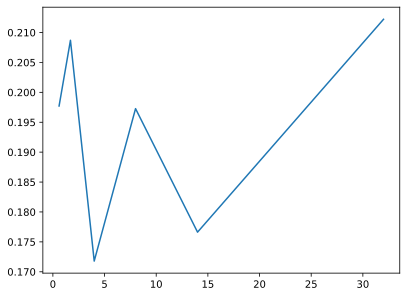

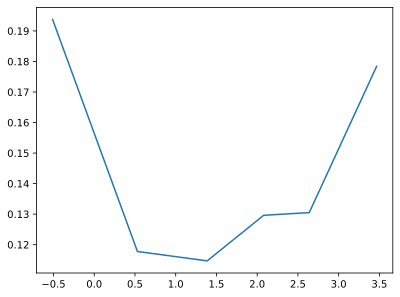

In [168]:
# this is the metric we care about... this is quite low tbh
# well this is basically fixed across models. 20% of the time it predicts switch (without) no switch (with)
df_1 = breast_cancer.groupby('parameter_count')['prediction_model_switch'].mean()
plt.plot(df_1)
plt.show()

# however this is more likely to be beneficial when the underlying model doesn't change behaviour
# stationary behaviour
plt.plot(df_gb['log'], df_gb['stationary_behaviour'])
plt.show()

# what percentage of the sim gain is this?


#### Experiment 2: Combined results

gemma_3


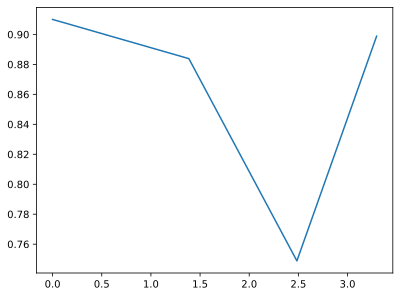

llama_2


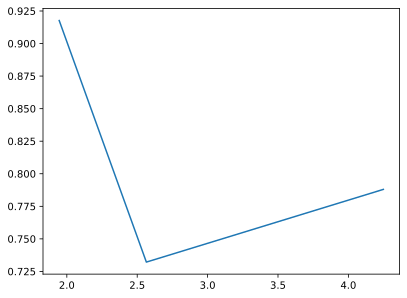

llama_3


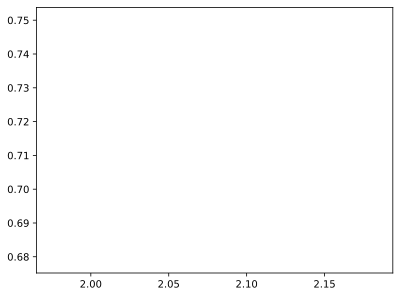

qwen_3


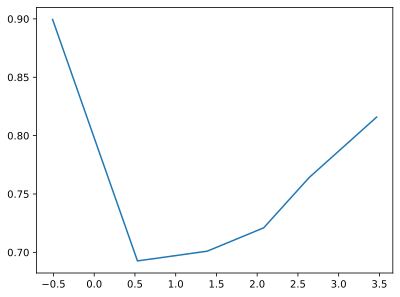

In [134]:
# load datasets
models = ['gemma_3', 'llama_2', 'llama_3', 'qwen_3']

for model in models:

    print(model)

    breast_cancer = pd.read_parquet(f"../experiments/breast_cancer/{model}/predictions.parquet")
    heart_disease = pd.read_parquet(f"../experiments/heart_disease/{model}/predictions.parquet")
    pima_diabetes = pd.read_parquet(f"../experiments/pima_diabetes/{model}/predictions.parquet")

    datasets = {"Breast Cancer":breast_cancer, "Heart Disease": heart_disease, "Diabetes": pima_diabetes}

    # best way to sample? for now just merge
    breast_cancer_sampled = breast_cancer.groupby('original_reference_response_model_info_model').sample(n=2000)
    heart_disease_sampled = heart_disease.groupby('original_reference_response_model_info_model').sample(n=2000)
    pima_diabetes_sampled = pima_diabetes.groupby('original_reference_response_model_info_model').sample(n=2000)
    df_combined = pd.concat([breast_cancer_sampled, heart_disease_sampled, pima_diabetes_sampled], ignore_index=True)

    # save combined file
    filepath = f"../experiments/combined/{model}"
    if not os.path.exists(filepath):
        os.makedirs(filepath)
    df_combined = df_combined.astype(str)
    df_combined.to_parquet(f"{filepath}/predictions.parquet")


    # calculate params
    def map_names(s):
        if 'Qwen' in s:
            return float(s.split("-")[-1].split("B")[0])
        elif 'gemma' in s:
            return float(s.split("-3-")[-1].split("b")[0])
        elif 'llama/Llama-2' in s:
            return float(s.split("-2-")[-1].split("b")[0])
        elif 'llama/Meta-Llama' in s:
            return float(s.split("-3-")[-1].split("B")[0])
        else:
            return s

    df_combined['parameter_count'] = df_combined['original_reference_response_model_info_model'].map(lambda x: map_names(x))

    # reference model switching. calculate mean True per model
    df_combined['reference_model_switch'] = (df_combined['original_reference_response_answer']==df_combined['counterfactual_reference_response_answer'])
    df_gb = df_combined.groupby(['parameter_count'])['reference_model_switch'].mean()
    df_gb = pd.DataFrame(df_gb)
    df_gb['log'] = df_gb.index.map(lambda x: np.log(x))
    df_gb.sort_index()
    plt.plot(df_gb['log'], df_gb['reference_model_switch'])
    plt.show()

In [133]:
df_gb

,reference_model_switch
parameter_count,
meta-llama/Meta-Llama-3-8B-Instruct,0.714


In [128]:
import numpy as np
df_gb = pd.DataFrame(df_gb)
df_gb['log'] = df_gb.index
t = df_gb.head(2)
t['log_'] = t.index.map(lambda x: np.log(x))
t

/tmp/ipykernel_202771/318889171.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t['log_'] = t.index.map(lambda x: np.log(x))


,reference_model_switch,log,log_
parameter_count,,,
1.0,0.907167,1.0,0.000000
4.0,0.884833,4.0,1.386294
